In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')

df = pd.read_csv('../data/clean_aqi.csv', parse_dates=['Date'])
df = df.sort_values(['City', 'Date']).reset_index(drop=True)

print(f"Loaded: {df.shape}")
print(f"Columns: {list(df.columns)}")

Loaded: (24850, 17)
Columns: ['City', 'Date', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'AQI', 'Year', 'Month', 'Day', 'DayOfWeek', 'Quarter']


In [2]:
# Lag features = past AQI values as input features
# "What was AQI yesterday? 3 days ago? 7 days ago?"

pollutant_cols = ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3']

# Create lag features within each city (NEVER across cities)
for lag in [1, 3, 7]:
    df[f'AQI_lag_{lag}'] = df.groupby('City')['AQI'].shift(lag)
    
# Also lag the main pollutants by 1 day
for col in ['PM2.5', 'PM10', 'NO2']:
    df[f'{col}_lag_1'] = df.groupby('City')[col].shift(1)

print("Lag features created:")
lag_cols = [c for c in df.columns if 'lag' in c]
print(lag_cols)

Lag features created:
['AQI_lag_1', 'AQI_lag_3', 'AQI_lag_7', 'PM2.5_lag_1', 'PM10_lag_1', 'NO2_lag_1']


In [3]:
# Rolling averages = smoothed trend over past N days
# Captures weekly and monthly pollution patterns

for window in [7, 14, 30]:
    df[f'AQI_rolling_{window}d'] = (
        df.groupby('City')['AQI']
        .transform(lambda x: x.shift(1).rolling(window, min_periods=1).mean())
    )

# Rolling std — captures how volatile/unstable AQI has been
df['AQI_rolling_7d_std'] = (
    df.groupby('City')['AQI']
    .transform(lambda x: x.shift(1).rolling(7, min_periods=1).std())
)

print("Rolling features created:")
roll_cols = [c for c in df.columns if 'rolling' in c]
print(roll_cols)

Rolling features created:
['AQI_rolling_7d', 'AQI_rolling_14d', 'AQI_rolling_30d', 'AQI_rolling_7d_std']


In [4]:
# India has 4 distinct pollution seasons
# Winter = highest AQI (cold traps pollution near ground)
# Monsoon = lowest AQI (rain washes pollution)

def get_season(month):
    if month in [12, 1, 2]:  return 'Winter'    # Highest pollution
    elif month in [3, 4, 5]: return 'Summer'
    elif month in [6, 7, 8, 9]: return 'Monsoon' # Lowest pollution
    else: return 'Post_Monsoon'                   # Rising again

df['Season'] = df['Month'].apply(get_season)

# Encode season as numbers for the model
season_map = {'Winter': 3, 'Post_Monsoon': 2, 'Summer': 1, 'Monsoon': 0}
df['Season_encoded'] = df['Season'].map(season_map)

print("Season distribution:")
print(df['Season'].value_counts())

Season distribution:
Season
Monsoon         7713
Summer          7069
Winter          6243
Post_Monsoon    3825
Name: count, dtype: int64


In [5]:
# Label encode City column

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['City_encoded'] = le.fit_transform(df['City'])

# Save the mapping so we can decode later
city_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print("City encoding:")
for city, code in city_mapping.items():
    print(f"  {city} → {code}")

City encoding:
  Ahmedabad → 0
  Aizawl → 1
  Amaravati → 2
  Amritsar → 3
  Bengaluru → 4
  Bhopal → 5
  Brajrajnagar → 6
  Chandigarh → 7
  Chennai → 8
  Coimbatore → 9
  Delhi → 10
  Ernakulam → 11
  Gurugram → 12
  Guwahati → 13
  Hyderabad → 14
  Jaipur → 15
  Jorapokhar → 16
  Kochi → 17
  Kolkata → 18
  Lucknow → 19
  Mumbai → 20
  Patna → 21
  Shillong → 22
  Talcher → 23
  Thiruvananthapuram → 24
  Visakhapatnam → 25


In [6]:
# Lag features create NaN for the first few rows of each city
# (e.g., Day 1 has no "yesterday" to look back at)
# We must drop these — they cannot be used for training

rows_before = len(df)
df = df.dropna(subset=[f'AQI_lag_{lag}' for lag in [1, 3, 7]])
rows_after = len(df)

print(f"Rows dropped due to lag NaNs: {rows_before - rows_after}")
print(f"Rows remaining: {rows_after:,}")
print(f"Total missing values: {df.isnull().sum().sum()}")

Rows dropped due to lag NaNs: 182
Rows remaining: 24,668
Total missing values: 6009


In [7]:
# These are the exact columns our model will use
feature_cols = [
    # Pollutants (current day readings)
    'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3',
    # Time features
    'Year', 'Month', 'Day', 'DayOfWeek', 'Quarter', 'Season_encoded',
    # Lag features (past AQI)
    'AQI_lag_1', 'AQI_lag_3', 'AQI_lag_7',
    # Lag pollutants
    'PM2.5_lag_1', 'PM10_lag_1', 'NO2_lag_1',
    # Rolling averages
    'AQI_rolling_7d', 'AQI_rolling_14d', 'AQI_rolling_30d',
    'AQI_rolling_7d_std',
    # City
    'City_encoded'
]

target_col = 'AQI'

print(f"Total features: {len(feature_cols)}")
print(f"\nFeature list:")
for i, f in enumerate(feature_cols, 1):
    print(f"  {i:2}. {f}")

Total features: 26

Feature list:
   1. PM2.5
   2. PM10
   3. NO
   4. NO2
   5. NOx
   6. NH3
   7. CO
   8. SO2
   9. O3
  10. Year
  11. Month
  12. Day
  13. DayOfWeek
  14. Quarter
  15. Season_encoded
  16. AQI_lag_1
  17. AQI_lag_3
  18. AQI_lag_7
  19. PM2.5_lag_1
  20. PM10_lag_1
  21. NO2_lag_1
  22. AQI_rolling_7d
  23. AQI_rolling_14d
  24. AQI_rolling_30d
  25. AQI_rolling_7d_std
  26. City_encoded


In [8]:
# CRITICAL: We split by TIME, not randomly
# Train on 2015-2019, Test on 2020
# This simulates real-world: model learns past, predicts future

train = df[df['Year'] < 2020].copy()
test  = df[df['Year'] == 2020].copy()

X_train = train[feature_cols]
y_train = train[target_col]

X_test = test[feature_cols]
y_test = test[target_col]

print(f"Training set : {X_train.shape}  ({train['Date'].min().date()} → {train['Date'].max().date()})")
print(f"Test set     : {X_test.shape}   ({test['Date'].min().date()} → {test['Date'].max().date()})")
print(f"\nTrain AQI mean: {y_train.mean():.1f}")
print(f"Test AQI mean : {y_test.mean():.1f}")

Training set : (20268, 26)  (2015-01-08 → 2019-12-31)
Test set     : (4400, 26)   (2020-01-01 → 2020-07-01)

Train AQI mean: 171.4
Test AQI mean : 112.4


In [9]:
# Save the feature-engineered dataset
df.to_csv('../data/featured_aqi.csv', index=False)

# Save feature list and train/test sets for modeling notebook
import joblib
joblib.dump(feature_cols, '../models/feature_cols.pkl')
joblib.dump(city_mapping, '../models/city_mapping.pkl')

X_train.to_csv('../data/X_train.csv', index=False)
X_test.to_csv('../data/X_test.csv', index=False)
y_train.to_csv('../data/y_train.csv', index=False)
y_test.to_csv('../data/y_test.csv', index=False)

print("✅ All files saved!")
print(f"   featured_aqi.csv : {df.shape}")
print(f"   X_train          : {X_train.shape}")
print(f"   X_test           : {X_test.shape}")

✅ All files saved!
   featured_aqi.csv : (24668, 30)
   X_train          : (20268, 26)
   X_test           : (4400, 26)


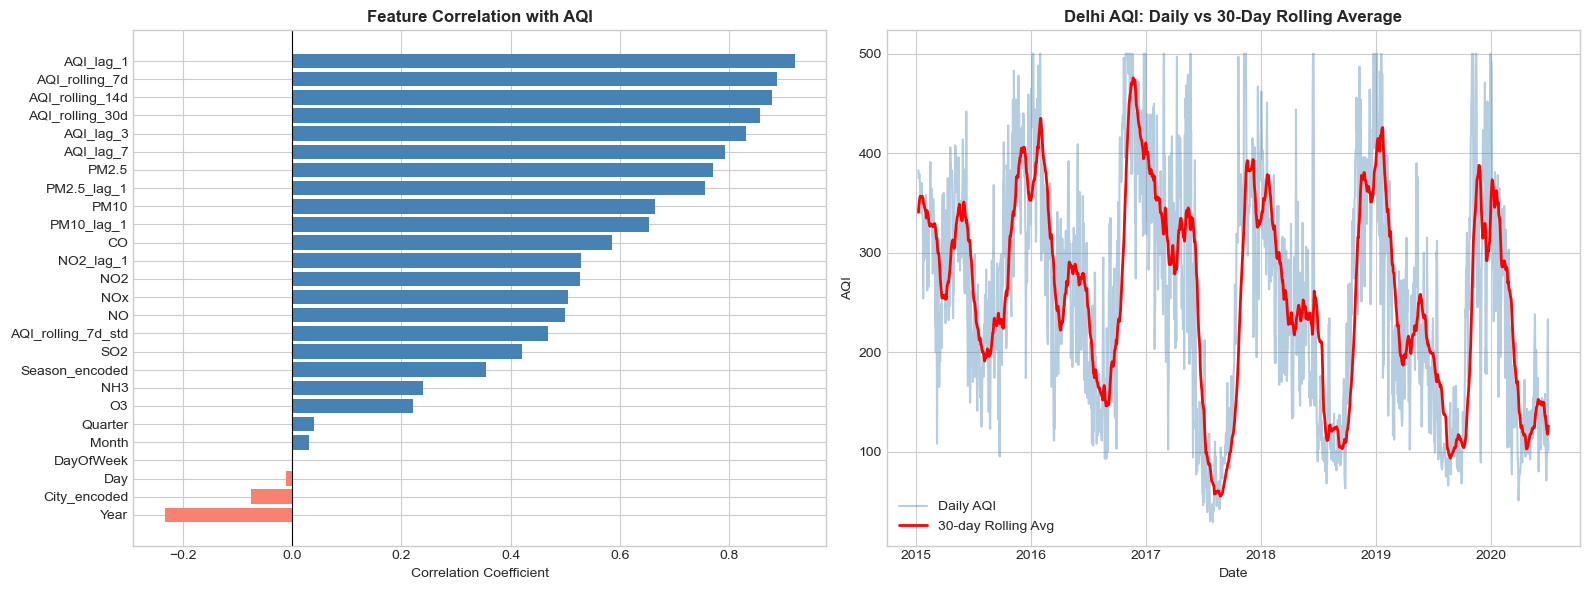

Plot saved ✓


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Correlation of all features with AQI
corr_with_aqi = df[feature_cols + ['AQI']].corr()['AQI'].drop('AQI').sort_values()

colors = ['salmon' if x < 0 else 'steelblue' for x in corr_with_aqi]
axes[0].barh(corr_with_aqi.index, corr_with_aqi.values, color=colors)
axes[0].set_title('Feature Correlation with AQI', fontweight='bold')
axes[0].set_xlabel('Correlation Coefficient')
axes[0].axvline(0, color='black', linewidth=0.8)

# AQI trend over time for Delhi
delhi = df[df['City'] == 'Delhi'].copy()
axes[1].plot(delhi['Date'], delhi['AQI'], alpha=0.4, color='steelblue', label='Daily AQI')
axes[1].plot(delhi['Date'], delhi['AQI_rolling_30d'], color='red', linewidth=2, label='30-day Rolling Avg')
axes[1].set_title('Delhi AQI: Daily vs 30-Day Rolling Average', fontweight='bold')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('AQI')
axes[1].legend()

plt.tight_layout()
plt.savefig('../visualizations/04_feature_engineering.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved ✓")